## Analyzing false positives in branchwater search

With reference to:

Ondov, B., Starrett, G., Sappington, A. et al. Mash Screen: high-throughput sequence containment estimation for genome discovery. Genome Biol 20, 232 (2019). https://doi.org/10.1186/s13059-019-1841-x

We can calculate the probability of a random *k*-mer occuring in a mixture using **Equation 5** from Ondov et al., 2019, by calculating the expected containment of A within B. More formally, the authors say: "Because the containment index does not depend on the size of the larger set, the expected containment of one random set, A, within another, B, is simply the probability *r* that a random *k*-mer, K, appears in B." If $n_B$ is the size of the mixture B, then this probability $r$ is:

$$
r = P(K \in B) = 4^{-k} n_B
$$

For the sourmash branchwater implementation of hashing, we divide the number of k-mers by a factor of 2 to account for canonical hashing, so the revised equation is:


$$
r' = P(K \in B) = 2 (4^{-k}) n_B
$$


We can then use this to calculate if the number of reference *k*-mers observed is statistically significant by modeling the the results using **Equation 6** from Ondov et al., 2019, and show it for *k*=21 and *k*=31.  Highlighted is a stringment *p*-value, where the odds of observing the effect randomly is less than 1 in 10 billion.  Here, s is the size of the query.

$$
P(X \geq x)
=
1-\sum_{i=0}^{x-1}
\binom{s}{i}
r^i(1-r)^{s-i}
$$

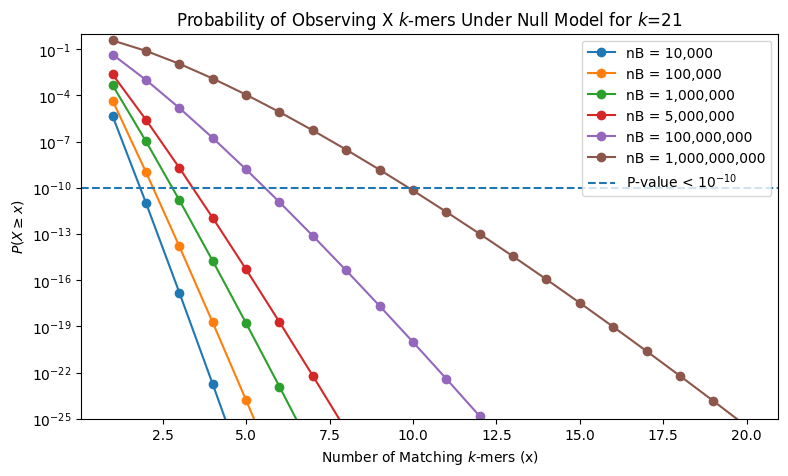

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

#Represents a mixture, so remove smallest set and add to largest set size. 
nB_values = [10_000, 100_000, 1_000_000, 5_000_000, 100_000_000, 1_000_000_000]

k = 21
s = 1_000

x_values = np.arange(1, 21)

plt.figure(figsize=(9, 5))

for nB in nB_values:

    r = 2 * (4.0 ** (-k)) * nB

    probabilities = binom.sf(x_values - 1, s, r)

    plt.plot(
        x_values,
        probabilities,
        marker="o",
        label=f"nB = {nB:,}"
    )

plt.yscale("log")

plt.xlabel("Number of Matching $k$-mers (x)")
plt.ylabel(r"$P(X \geq x)$")
plt.title("Probability of Observing X $k$-mers Under Null Model for $k$=21")
plt.axhline(1e-10, linestyle="--", label="P-value < $10^{-10}$")

plt.ylim(1e-25, 1)

plt.legend()
plt.show()

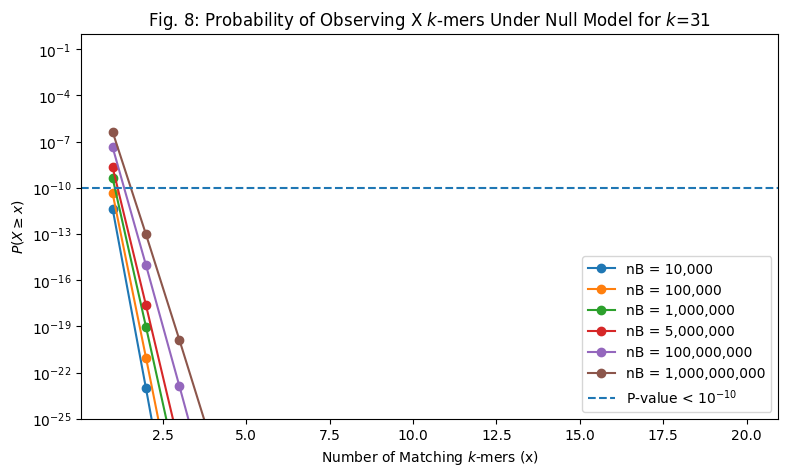

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

#Represents a mixture, so remove smallest set and add to largest set size. 
nB_values = [10_000, 100_000, 1_000_000, 5_000_000, 100_000_000, 1_000_000_000]

k = 31
s = 1_000

x_values = np.arange(1, 21)

plt.figure(figsize=(9, 5))

for nB in nB_values:

    r = 2 * (4.0 ** (-k)) * nB

    probabilities = binom.sf(x_values - 1, s, r)

    plt.plot(
        x_values,
        probabilities,
        marker="o",
        label=f"nB = {nB:,}"
    )

plt.yscale("log")

plt.xlabel("Number of Matching $k$-mers (x)")
plt.ylabel(r"$P(X \geq x)$")
plt.title("Fig. 8: Probability of Observing X $k$-mers Under Null Model for $k$=31")
plt.axhline(1e-10, linestyle="--", label="P-value < $10^{-10}$")

plt.ylim(1e-25, 1)

plt.legend()
plt.show()

## Calculating the p-value given nB, k, s, and X.

X: number of matching hashes.

s: size of query sketch.

nB: size of metagenome.

k: k-mer size.

In [3]:
def p_of_match(query_size, metag_size, n_matches, ksize):
    k = ksize
    s = query_size
    nB = metag_size
    X = n_matches

    r = 2*(4.0 ** (-k)) * nB

    prob = binom.sf(X - 1, s, r)
    return float(prob)

p_of_match(1000, 1e8, 5, 21)


1.545087672220841e-09

# Graph p-values vs num hashes for a few different query sizes

Text(0.5, 1.0, 'p values for number of matches found using background model')

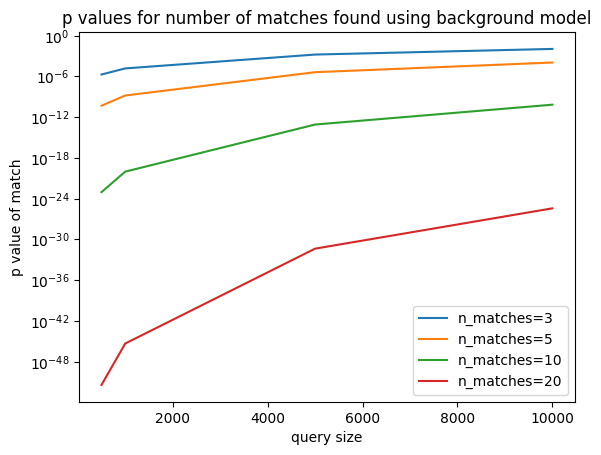

In [4]:
metag_size = 1e8
ksize=21
n_matches = 20
qsizes = [500, 1000, 5000, 10_000]

plt.yscale('log')
for n_matches in [3, 5, 10, 20]:
    pvalues = []
    for qsize in qsizes:
        pvalues.append(p_of_match(qsize, metag_size, n_matches, ksize))
    
    plt.plot(qsizes, pvalues, label=f'n_matches={n_matches}')

plt.legend(loc='lower right')
plt.xlabel('query size')
plt.ylabel('p value of match')
plt.title('p values for number of matches found using background model')

# Annotate random query results with p-values

I'm not actually sure why I thought this was useful but I'm leaving it here for now.

## Load random query results

In [5]:
import polars as pl

wort_df = pl.read_csv(f"wort-false-positive-subset-3000-details.csv")
results_df = pl.read_csv(f"false-positive-subset-3000-results.csv")

# standardize the query column name.
if "query" not in results_df.columns:
    results_df = results_df.rename({"query_name": "query"})

# identify the unique queries represented in the results.
queries_df = results_df.select("query").unique()
n_queries = queries_df.height
expected_comparisons = n_queries * wort_df.height

# create every possible query–metagenome pair.
all_pairs = queries_df.join(
    wort_df.rename({"name": "match_name"}),
    how="cross",
)

# preserve whether a pair was actually present in the results file.
results_df = results_df.with_columns(
    pl.lit(True).alias("reported_result")
)

# attach existing results; retain pairs with no reported match.
combined_df = (
    all_pairs
    .join(
        results_df,
        on=["query", "match_name"],
        how="left",
        suffix="_result",
        validate="1:1",
    )
    .with_columns(
        pl.col("containment").fill_null(0.0),
        pl.col("intersect_hashes").fill_null(0),
        pl.col("reported_result").fill_null(False),
        qsize=pl.col("query").str.split('=').list.get(1).cast(pl.Int32),
    )
    .sort(["query", "n_hashes"])
)

n_added = combined_df.filter(~pl.col("reported_result")).height

print(f"Unique queries: {n_queries:,}")
print(f"Metagenomes: {wort_df.height:,}")
print(f"Expected Comparisons: {expected_comparisons:,}")
print(f"Final Comparisons: {combined_df.height:,}")
print(f"Pairs Added with Zero Containment: {n_added:,}")

# estimate containment from the number of distinct k-mers before sketching.
combined_df = (combined_df
    .with_columns(
        (pl.col("n_hashes").cast(pl.Float64) *
         pl.col("scaled")).alias("nB")
    ).with_columns(
        ((4.0 ** (-21)) * 2 * pl.col("nB")).alias("expected_containment"),
        pl.col('n_hashes').alias('metag_size'),
        pl.col('match_name').alias('metag_name'),
        
    )
    .with_row_index(name='index')
)

combined_df = combined_df.select(['index',
                                  'query',
                                  'qsize',
                                  'metag_name',
                                  'metag_size',
                                  'ksize',
                                  'scaled',
                                  'containment',
                                  'intersect_hashes',
                                  'expected_containment',
                                  'nB',])

Unique queries: 4
Metagenomes: 2,822
Expected Comparisons: 11,288
Final Comparisons: 11,288
Pairs Added with Zero Containment: 9,887


## Compute a p-value column for each row

In [6]:
pval_xx = []

for row in combined_df.iter_rows(named=True):
    row_index = row["index"]
    ksize = row["ksize"]
    metag_size = row["metag_size"]
    qsize = row["qsize"]
    n_matches = row["intersect_hashes"]

    pval = p_of_match(qsize, metag_size, n_matches, ksize)
    pval_xx.append(dict(index=row_index, pval=pval))

pval_df = pl.DataFrame(pval_xx)

In [7]:
# join
combined2_df = combined_df.join(pval_df, on='index', how='inner')

In [8]:
combined2_df

index,query,qsize,metag_name,metag_size,ksize,scaled,containment,intersect_hashes,expected_containment,nB,pval
u32,str,i32,str,i64,i64,i64,f64,i64,f64,f64,f64
0,"""qsize=100""",100,"""ERR1739527""",1,21,1000,0.0,0,4.5475e-10,1000.0,1.0
1,"""qsize=100""",100,"""SRR26109990""",1,21,1000,0.0,0,4.5475e-10,1000.0,1.0
2,"""qsize=100""",100,"""SRR16965339""",1,21,1000,0.0,0,4.5475e-10,1000.0,1.0
3,"""qsize=100""",100,"""ERR12006534""",1,21,1000,0.0,0,4.5475e-10,1000.0,1.0
4,"""qsize=100""",100,"""SRR386725""",1,21,1000,0.0,0,4.5475e-10,1000.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…
11283,"""qsize=5000""",5000,"""SRR26348422""",11295015,21,1000,0.005,25,0.005136,1.1295e10,1.0310e-65
11284,"""qsize=5000""",5000,"""SRR28401788""",12615176,21,1000,0.005,25,0.005737,1.2615e10,1.6299e-64
11285,"""qsize=5000""",5000,"""SRR11211956""",16965486,21,1000,0.005,25,0.007715,1.6965e10,2.6600e-61
